In [2]:
import pandas as pd
import ollama
from urllib.parse import urlparse, parse_qs
from tqdm import tqdm

In [4]:
data=pd.read_csv("url_dataset.csv")

In [5]:
data.head()

,url,type
0,https://www.google.com,legitimate
1,https://www.youtube.com,legitimate
2,https://www.facebook.com,legitimate
3,https://www.baidu.com,legitimate
4,https://www.wikipedia.org,legitimate


In [8]:
data.tail()

,url,type
450171,http://ecct-it.com/docmmmnn/aptgd/index.php,phishing
450172,http://faboleena.com/js/infortis/jquery/plugin...,phishing
450173,http://faboleena.com/js/infortis/jquery/plugin...,phishing
450174,http://atualizapj.com/,phishing
450175,http://writeassociate.com/test/Portal/inicio/I...,phishing


In [9]:
data.describe()

,url,type
count,450176,450176
unique,450176,2
top,http://www.visaofakebook.info/,legitimate
freq,1,345738


In [10]:
data.dtypes

url     object
type    object
dtype: object

In [11]:
# Filter the data into legitimate and phishing sites
legitimate_df = data[data['type'] == 'legitimate']
phishing_df = data[data['type'] == 'phishing']

# Randomly sample 75,000 rows from each category (total 150,000)
legitimate_sample = legitimate_df.sample(n=75000, random_state=42)
phishing_sample = phishing_df.sample(n=75000, random_state=42)

# Combine the samples into one dataset
balanced_sample = pd.concat([legitimate_sample, phishing_sample])

# Shuffle the combined dataset (optional)
balanced_sample = balanced_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced sampled data to a new CSV file
balanced_sample.to_csv('sampled_data.csv', index=False)

# Optionally, print the first few rows of the balanced data
print(balanced_sample.head())

                                                 url        type
0            https://www.beroyalairforce.tumblr.com/  legitimate
1                             https://www.colts.com/  legitimate
2  http://printfastvegas.com/create/GOOGLENEWW/GO...    phishing
3  http://neaindustrias.com/Image/Googleddrive/Go...    phishing
4                       http://87.120.37.90/fend.png    phishing


In [12]:
df=pd.read_csv("sampled_data.csv")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     150000 non-null  object
 1   type    150000 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


In [14]:
df.describe()

,url,type
count,150000,150000
unique,150000,2
top,https://sites.google.com/site/wwwpagesinfo094/,legitimate
freq,1,75000


In [15]:
df.dtypes

url     object
type    object
dtype: object

C:\Users\Admin\AppData\Local\Temp\ipykernel_21860\3514602191.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


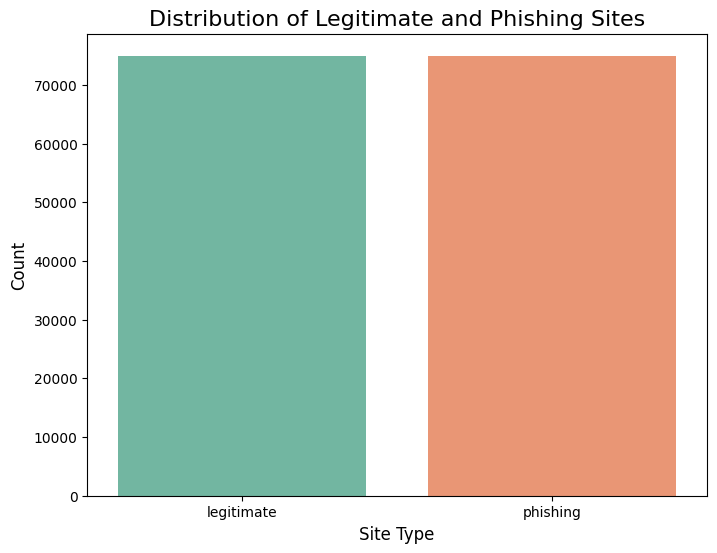

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Plot the distribution of 'type' column (legitimate vs phishing)
plt.figure(figsize=(8, 6))

# Count the occurrences of each type (legitimate and phishing)
sns.countplot(x='type', data=df, palette='Set2')

# Set title and labels
plt.title('Distribution of Legitimate and Phishing Sites', fontsize=16)
plt.xlabel('Site Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show the plot
plt.show()

In [19]:
# Convert 'type' column (Label Encoding)
df['type'] = df['type'].map({'phishing': 1, 'legitimate': 0})

In [20]:
# Function to tokenize URLs
def tokenize_url(url):
    parsed = urlparse(url)
    return {
        "protocol": parsed.scheme,
        "domain": parsed.netloc,
        "path": parsed.path,
        "num_query_params": len(parse_qs(parsed.query)),
        "has_login": 1 if "login" in parsed.path.lower() or "signin" in parsed.path.lower() else 0,
        "has_ip": 1 if any(char.isdigit() for char in parsed.netloc) else 0,
    }

In [22]:
df_tokens = df['url'].apply(tokenize_url).apply(pd.Series)

# Select key parts for embedding
df['text_for_embedding'] = df_tokens['domain'] + " " + df_tokens['path']


In [23]:
tqdm.pandas()

In [24]:
def get_embedding(text):
    response = ollama.embeddings(model="mistral", prompt=text)
    return response['embedding']

In [25]:

# Split the data into 5 blocks of 30k each
num_blocks = 5
block_size = 30000
num_rows = len(df)

In [19]:
# Generate embeddings for each block and save them as separate CSVs
for block_num in range(num_blocks):
    start_idx = block_num * block_size
    end_idx = min((block_num + 1) * block_size, num_rows)

    # Select the current block
    df_block = df.iloc[start_idx:end_idx].copy()

    # Tokenize URLs for the current block
    df_tokens_block = df_block['url'].apply(tokenize_url).apply(pd.Series)

    # Generate text for embedding
    df_block['text_for_embedding'] = df_tokens_block['domain'] + " " + df_tokens_block['path']

    # Get embeddings for the current block
    tqdm.pandas()  # Enable progress bar
    df_block['embedding'] = df_block['text_for_embedding'].progress_apply(get_embedding)

    # Convert embeddings into separate columns
    embedding_df = pd.DataFrame(df_block['embedding'].tolist(), index=df_block.index)

    # Concatenate the embeddings with the tokenized columns
    df_block = pd.concat([df_block.drop(columns=['embedding', 'text_for_embedding']),
                          df_tokens_block, embedding_df], axis=1)

    # Save the current block to a new CSV
    df_block.to_csv(f"processed_data_block_{block_num + 1}.csv", index=False)

    print(f"Processed and saved block {block_num + 1}.")


100%|██████████| 30000/30000 [9:30:12<00:00,  1.14s/it]   


Processed and saved block 1.


100%|██████████| 30000/30000 [9:23:46<00:00,  1.13s/it]   


Processed and saved block 2.


100%|██████████| 30000/30000 [8:36:57<00:00,  1.03s/it]   


Processed and saved block 3.


100%|██████████| 30000/30000 [8:45:17<00:00,  1.05s/it]   


Processed and saved block 4.


100%|██████████| 30000/30000 [8:18:52<00:00,  1.00it/s]   


Processed and saved block 5.


In [20]:

import glob

# List of CSV file names
file_paths = [
    'processed_data_block_1.csv',
    'processed_data_block_2.csv',
    'processed_data_block_3.csv',
    'processed_data_block_4.csv',
    'processed_data_block_5.csv'
]

# Read and concatenate all CSV files
dataframes = [pd.read_csv(file) for file in file_paths]
concatenated_data = pd.concat(dataframes, ignore_index=True)

# Save the concatenated dataframe to a new CSV file
concatenated_data.to_csv('concatenated_data.csv', index=False)

print("Files have been concatenated and saved as 'concatenated_data.csv'.")


Files have been concatenated and saved as 'concatenated_data.csv'.


In [21]:
d1=pd.read_csv("concatenated_data.csv")

In [22]:
d1.head()

,url,type,protocol,domain,path,num_query_params,has_login,has_ip,0,1,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,https://www.beroyalairforce.tumblr.com/,0,https,www.beroyalairforce.tumblr.com,/,0,0,0,4.536286,7.701725,...,-5.365789,0.661055,1.072909,16.016500,6.886988,9.750399,3.833262,-0.136868,-4.483562,-2.508195
1,https://www.colts.com/,0,https,www.colts.com,/,0,0,0,-1.359303,4.204414,...,-3.389442,-0.089229,3.035681,17.113449,2.682641,22.024849,8.846536,4.660522,-0.502236,-9.381823
2,http://printfastvegas.com/create/GOOGLENEWW/GO...,1,http,printfastvegas.com,/create/GOOGLENEWW/GOOGLENEWW/GOOGLENEW/reales...,0,0,0,0.373590,-0.286500,...,-10.004152,-1.861899,-0.639365,5.958819,4.518531,21.813799,-1.802695,-1.046291,2.440579,1.401767
3,http://neaindustrias.com/Image/Googleddrive/Go...,1,http,neaindustrias.com,/Image/Googleddrive/Googledrives90444/Googledo...,0,0,0,3.711474,3.619465,...,-3.650945,0.683283,-0.408646,7.276477,2.935656,23.817551,-3.225528,2.555102,-0.073119,-0.606580
4,http://forestnice.com/download/6C156D35.zip,1,http,forestnice.com,/download/6C156D35.zip,0,0,0,1.006960,0.770139,...,3.631575,-5.442421,-10.027542,9.492413,6.449296,17.067564,-0.603650,-2.505689,0.301159,-9.932166


In [23]:
d1.tail()

,url,type,protocol,domain,path,num_query_params,has_login,has_ip,0,1,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
149995,http://manaveeyamnews.com/css/sed/GD/PI/e8c436...,1,http,manaveeyamnews.com,/css/sed/GD/PI/e8c43695d45587a2c28b0807bb7d5a5f/,0,0,0,4.173977,-2.229608,...,-3.362393,-1.575635,-0.704248,8.579866,4.025735,25.490976,2.682992,1.736683,1.863378,-2.266919
149996,http://sacurity-info-notif2018.000webhostapp.c...,1,http,sacurity-info-notif2018.000webhostapp.com,/Payment-update-0.html,1,0,1,-2.158694,-1.146553,...,0.353202,-3.566556,-4.773314,7.185727,3.307973,27.476616,5.263036,-0.130647,3.861647,-8.604733
149997,http://kinecc8787.esy.es/,1,http,kinecc8787.esy.es,/,0,0,1,2.643696,2.724709,...,-5.732486,-2.479688,1.402612,9.367638,1.411146,10.277599,-3.060175,-1.131238,-3.182764,-7.005327
149998,http://fellinio.cf/Uk9HSwQAWEsGS1FPUVJbWwtdXlg...,1,http,fellinio.cf,/Uk9HSwQAWEsGS1FPUVJbWwtdXlgZVARPBgcEGVMBGQ4ZB...,0,0,0,-10.212866,5.927673,...,4.594451,-9.185962,-2.528188,1.137950,0.925131,10.463925,7.730248,1.898516,0.325193,-7.357196
149999,http://www.bibwebshop.com/RES1011/m1cros0fts/i...,1,http,www.bibwebshop.com,/RES1011/m1cros0fts/indexa.php,0,0,0,-1.045579,3.161331,...,-2.774963,-5.437674,-2.010875,7.453729,3.781839,31.564962,1.282577,-4.143922,6.903481,-2.425421


In [24]:
d1.info

<bound method DataFrame.info of                                                       url  type protocol  \
0                 https://www.beroyalairforce.tumblr.com/     0    https   
1                                  https://www.colts.com/     0    https   
2       http://printfastvegas.com/create/GOOGLENEWW/GO...     1     http   
3       http://neaindustrias.com/Image/Googleddrive/Go...     1     http   
4             http://forestnice.com/download/6C156D35.zip     1     http   
...                                                   ...   ...      ...   
149995  http://manaveeyamnews.com/css/sed/GD/PI/e8c436...     1     http   
149996  http://sacurity-info-notif2018.000webhostapp.c...     1     http   
149997                          http://kinecc8787.esy.es/     1     http   
149998  http://fellinio.cf/Uk9HSwQAWEsGS1FPUVJbWwtdXlg...     1     http   
149999  http://www.bibwebshop.com/RES1011/m1cros0fts/i...     1     http   

                                           domain  \
0 

In [25]:
d1.describe()

,type,num_query_params,has_login,has_ip,0,1,2,3,4,5,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.500000,0.260200,0.037507,0.104100,0.882210,1.289594,0.196322,0.035230,2.261339,1.016148,...,-0.281970,-4.226298,-2.068584,7.256444,2.332808,18.279081,3.192279,-0.369966,1.378403,-2.867617
std,0.500002,0.878541,0.190000,0.305391,3.334864,3.510477,3.342879,3.831729,3.507168,4.861266,...,4.337176,3.777940,3.352802,5.834170,3.493551,10.262455,4.278732,4.144600,4.402003,4.457192
min,0.000000,0.000000,0.000000,0.000000,-18.214502,-21.822687,-18.171127,-20.779150,-14.923450,-22.555340,...,-18.962963,-21.492039,-19.395571,-25.741135,-15.154643,-52.866802,-17.715858,-18.185703,-19.597208,-22.989132
25%,0.000000,0.000000,0.000000,0.000000,-1.341718,-0.936393,-1.937472,-2.583845,-0.098888,-2.447860,...,-3.259664,-6.938211,-4.216873,3.559355,0.072314,12.859171,0.255373,-2.945161,-1.672344,-5.591863
50%,0.500000,0.000000,0.000000,0.000000,0.990312,1.294246,0.283948,0.125113,2.055262,0.679789,...,0.162892,-4.124447,-1.894434,7.333677,2.386666,18.764170,3.047523,-0.229408,1.515002,-2.586912
75%,1.000000,0.000000,0.000000,0.000000,3.184255,3.627597,2.390134,2.628376,4.518065,4.364866,...,2.895061,-1.585923,0.296151,11.094864,4.670670,24.867005,5.845644,2.408318,4.505167,0.042250
max,1.000000,29.000000,1.000000,1.000000,17.267864,17.702398,15.692766,20.054699,19.287682,21.631102,...,17.266996,13.679637,14.150562,33.440895,17.868174,53.949409,23.388260,17.758709,18.715748,15.785110


In [26]:
d1.dtypes

url          object
type          int64
protocol     object
domain       object
path         object
             ...   
4091        float64
4092        float64
4093        float64
4094        float64
4095        float64
Length: 4104, dtype: object